In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [2]:
import zipfile

print("🔄 Unzipping waste.zip from Drive...")
with zipfile.ZipFile('/content/drive/MyDrive/waste.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/waste_data')
print("✅ Unzip complete!")

🔄 Unzipping waste.zip from Drive...
✅ Unzip complete!


In [3]:
!pip install -q tensorflow scikit-learn seaborn matplotlib
print("✅ Libraries installed!")

✅ Libraries installed!


In [4]:
import pathlib
import numpy as np

data_path = '/content/waste_data/waste'
data_dir = pathlib.Path(data_path)
classes = sorted([f.name for f in data_dir.iterdir() if f.is_dir()])

print("✅ Classes found:", classes)
print("\n📊 Image counts:")
total = 0
for cls in classes:
    count = len(list((data_dir / cls).glob('*.*')))
    total += count
    print(f"   ✅ {cls}: {count} images")
print(f"\n   🔥 Total: {total} images")

✅ Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

📊 Image counts:
   ✅ cardboard: 2214 images
   ✅ glass: 2500 images
   ✅ metal: 2084 images
   ✅ paper: 2315 images
   ✅ plastic: 2288 images
   ✅ trash: 2653 images

   🔥 Total: 14054 images


In [5]:
import shutil
from sklearn.model_selection import train_test_split

TRAIN_DIR = '/content/dataset/train'
VAL_DIR   = '/content/dataset/val'
TEST_DIR  = '/content/dataset/test'

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

print("🔄 Splitting 70% / 15% / 15%...")
summary = {}
for cls in classes:
    cls_path = os.path.join(data_path, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    train_imgs, temp = train_test_split(
        images, test_size=0.30, random_state=42
    )
    val_imgs, test_imgs = train_test_split(
        temp, test_size=0.50, random_state=42
    )
    for img in train_imgs:
        shutil.copy2(
            os.path.join(cls_path, img),
            os.path.join(TRAIN_DIR, cls, img)
        )
    for img in val_imgs:
        shutil.copy2(
            os.path.join(cls_path, img),
            os.path.join(VAL_DIR, cls, img)
        )
    for img in test_imgs:
        shutil.copy2(
            os.path.join(cls_path, img),
            os.path.join(TEST_DIR, cls, img)
        )
    summary[cls] = {
        'train': len(train_imgs),
        'val':   len(val_imgs),
        'test':  len(test_imgs)
    }
    print(f"   ✅ {cls}: {len(train_imgs)} train | "
          f"{len(val_imgs)} val | {len(test_imgs)} test")

print(f"\n✅ Train: {sum(v['train'] for v in summary.values())}")
print(f"✅ Val:   {sum(v['val']   for v in summary.values())}")
print(f"✅ Test:  {sum(v['test']  for v in summary.values())}")

🔄 Splitting 70% / 15% / 15%...
   ✅ cardboard: 1549 train | 332 val | 333 test
   ✅ glass: 1750 train | 375 val | 375 test
   ✅ metal: 1458 train | 313 val | 313 test
   ✅ paper: 1620 train | 347 val | 348 test
   ✅ plastic: 1601 train | 343 val | 344 test
   ✅ trash: 1857 train | 398 val | 398 test

✅ Train: 9835
✅ Val:   2108
✅ Test:  2111


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow: 2.20.0
✅ GPU: True


In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    fill_mode='nearest'
)

test_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(300, 300),
    batch_size=16,
    shuffle=True,
    class_mode='categorical'
)
val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(300, 300),
    batch_size=16,
    shuffle=False,
    class_mode='categorical'
)
test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(300, 300),
    batch_size=16,
    shuffle=False,
    class_mode='categorical'
)

print(f"\n✅ Class indices: {train_gen.class_indices}")
print(f"✅ Train:      {train_gen.samples} images")
print(f"✅ Validation: {val_gen.samples} images")
print(f"✅ Test:       {test_gen.samples} images")

Found 9835 images belonging to 6 classes.
Found 2108 images belonging to 6 classes.
Found 2111 images belonging to 6 classes.

✅ Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
✅ Train:      9835 images
✅ Validation: 2108 images
✅ Test:       2111 images


In [8]:
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

print("✅ Class Weights:")
for idx, weight in class_weight_dict.items():
    cls_name = list(train_gen.class_indices.keys())[idx]
    print(f"   {cls_name}: {weight:.4f}")

✅ Class Weights:
   cardboard: 1.0582
   glass: 0.9367
   metal: 1.1243
   paper: 1.0118
   plastic: 1.0238
   trash: 0.8827


In [9]:
print("\n🔨 Building EfficientNetB3...")

base_model = EfficientNetB3(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    512, activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.0005)
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(
    256, activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.0005)
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(6, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)
print(f"✅ Total layers:     {len(model.layers)}")
print(f"✅ Total parameters: {model.count_params():,}")


🔨 Building EfficientNetB3...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ Total layers:     393
✅ Total parameters: 11,706,421


In [12]:
print("\n🚀 Phase 1: Warmup Training...")
os.makedirs('/content/drive/MyDrive/WasteModel', exist_ok=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        # ✅ Fixed - .weights.h5
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/WasteModel/phase1_epoch_{epoch:03d}_acc_{val_accuracy:.4f}.weights.h5',
            save_best_only=False,
            save_weights_only=True,
            verbose=1
        ),

        # ✅ Same - full model
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/WasteModel/phase1_BEST.h5',
            save_best_only=True,
            save_weights_only=False,
            monitor='val_accuracy',
            verbose=1
        )
    ]
)

best1 = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 Complete!")
print(f"✅ Best Val Accuracy: {best1*100:.2f}%")
print(f"✅ Saved to Drive/WasteModel/")


🚀 Phase 1: Warmup Training...
Epoch 1/25
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6888 - loss: 1.8127
Epoch 1: saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_001_acc_0.8800.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_001_acc_0.8800.weights.h5

Epoch 1: val_accuracy improved from None to 0.87998, saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5



Epoch 1: finished saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 385s 540ms/step - accuracy: 0.7499 - loss: 1.6375 - val_accuracy: 0.8800 - val_loss: 1.3049
Epoch 2/25
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8243 - loss: 1.4131
Epoch 2: saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_002_acc_0.9099.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_002_acc_0.9099.weights.h5

Epoch 2: val_accuracy improved from 0.87998 to 0.90987, saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5



Epoch 2: finished saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 269s 436ms/step - accuracy: 0.8282 - loss: 1.3894 - val_accuracy: 0.9099 - val_loss: 1.1854
Epoch 3/25
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8526 - loss: 1.2907
Epoch 3: saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_003_acc_0.9103.weights.h5

Epoch 3: finished saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_003_acc_0.9103.weights.h5

Epoch 3: val_accuracy improved from 0.90987 to 0.91034, saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5



Epoch 3: finished saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 269s 438ms/step - accuracy: 0.8500 - loss: 1.2738 - val_accuracy: 0.9103 - val_loss: 1.1011
Epoch 4/25
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8631 - loss: 1.1920
Epoch 4: saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_004_acc_0.9217.weights.h5

Epoch 4: finished saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_004_acc_0.9217.weights.h5

Epoch 4: val_accuracy improved from 0.91034 to 0.92173, saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5



Epoch 4: finished saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 319s 433ms/step - accuracy: 0.8600 - loss: 1.1809 - val_accuracy: 0.9217 - val_loss: 1.0259
Epoch 5/25
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8583 - loss: 1.1388
Epoch 5: saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_005_acc_0.9274.weights.h5

Epoch 5: finished saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_005_acc_0.9274.weights.h5

Epoch 5: val_accuracy improved from 0.92173 to 0.92742, saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5



Epoch 5: finished saving model to /content/drive/MyDrive/WasteModel/phase1_BEST.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 320s 431ms/step - accuracy: 0.8553 - loss: 1.1331 - val_accuracy: 0.9274 - val_loss: 0.9872
Epoch 6/25
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8671 - loss: 1.0877
Epoch 6: saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_006_acc_0.9208.weights.h5

Epoch 6: finished saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_006_acc_0.9208.weights.h5

Epoch 6: val_accuracy did not improve from 0.92742
615/615 ━━━━━━━━━━━━━━━━━━━━ 262s 426ms/step - accuracy: 0.8640 - loss: 1.0860 - val_accuracy: 0.9208 - val_loss: 0.9667
Epoch 7/25
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8557 - loss: 1.0910
Epoch 7: saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_007_acc_0.9165.weights.h5

Epoch 7: finished saving model to /content/drive/MyDrive/WasteModel/phase1_epoch_007_acc_0.9165.weights.h5

Epoch 7: val_accuracy did not imp

In [14]:

print("\n🔧 Phase 2: Fine-Tuning...")

base_model.trainable = True

for layer in base_model.layers[:-100]:

    layer.trainable = False

print(f"✅ Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),

    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),

    metrics=['accuracy']

)

# Custom logger

class EpochLogger(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):

        print(f"\n{'='*50}")

        print(f"📌 Phase 2 — Epoch {epoch+1} Complete!")

        print(f"   Train Acc:  {logs['accuracy']*100:.2f}%")

        print(f"   Val Acc:    {logs['val_accuracy']*100:.2f}%")

        print(f"   Train Loss: {logs['loss']:.4f}")

        print(f"   Val Loss:   {logs['val_loss']:.4f}")

        print(f"   ✅ Saved to Drive!")

        print(f"{'='*50}\n")

history2 = model.fit(

    train_gen,

    epochs=500,

    validation_data=val_gen,

    class_weight=class_weight_dict,

    callbacks=[

        tf.keras.callbacks.EarlyStopping(

            monitor='val_accuracy',

            patience=10,

            restore_best_weights=True,

            verbose=1

        ),

        tf.keras.callbacks.ReduceLROnPlateau(

            monitor='val_loss',

            factor=0.3,

            patience=3,

            min_lr=1e-8,

            verbose=1

        ),

        # ✅ HAR EPOCH WEIGHTS SAVE — ~10MB per epoch

        tf.keras.callbacks.ModelCheckpoint(

            '/content/drive/MyDrive/WasteModel/phase2_epoch_{epoch:03d}_acc_{val_accuracy:.4f}.weights.h5',

            save_best_only=False,

            save_weights_only=True,

            verbose=0

        ),

        # ✅ BEST POORA MODEL SAVE

        tf.keras.callbacks.ModelCheckpoint(

            '/content/drive/MyDrive/WasteModel/BEST_MODEL.h5',

            save_best_only=True,

            save_weights_only=False,

            monitor='val_accuracy',

            verbose=1

        ),

        # ✅ HAR EPOCH PRINT

        EpochLogger()

    ]

)

best2 = max(history2.history['val_accuracy'])

print(f"\n🎉 Phase 2 Complete!")

print(f"🎉 Best Val Accuracy: {best2*100:.2f}%")


🔧 Phase 2: Fine-Tuning...
✅ Trainable layers: 108
Epoch 1/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.7812 - loss: 1.2684
Epoch 1: val_accuracy improved from None to 0.89943, saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5



Epoch 1: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 1 Complete!
   Train Acc:  80.77%
   Val Acc:    89.94%
   Train Loss: 1.2184
   Val Loss:   1.0372
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 403s 549ms/step - accuracy: 0.8077 - loss: 1.2184 - val_accuracy: 0.8994 - val_loss: 1.0372 - learning_rate: 1.0000e-05
Epoch 2/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8327 - loss: 1.1535
Epoch 2: val_accuracy improved from 0.89943 to 0.91461, saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5



Epoch 2: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 2 Complete!
   Train Acc:  83.70%
   Val Acc:    91.46%
   Train Loss: 1.1482
   Val Loss:   1.0026
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 283s 460ms/step - accuracy: 0.8370 - loss: 1.1482 - val_accuracy: 0.9146 - val_loss: 1.0026 - learning_rate: 1.0000e-05
Epoch 3/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8590 - loss: 1.1078
Epoch 3: val_accuracy improved from 0.91461 to 0.92125, saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5



Epoch 3: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 3 Complete!
   Train Acc:  86.60%
   Val Acc:    92.13%
   Train Loss: 1.0927
   Val Loss:   0.9831
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 278s 452ms/step - accuracy: 0.8660 - loss: 1.0927 - val_accuracy: 0.9213 - val_loss: 0.9831 - learning_rate: 1.0000e-05
Epoch 4/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8707 - loss: 1.0858
Epoch 4: val_accuracy improved from 0.92125 to 0.92600, saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5



Epoch 4: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 4 Complete!
   Train Acc:  87.52%
   Val Acc:    92.60%
   Train Loss: 1.0750
   Val Loss:   0.9652
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 276s 448ms/step - accuracy: 0.8752 - loss: 1.0750 - val_accuracy: 0.9260 - val_loss: 0.9652 - learning_rate: 1.0000e-05
Epoch 5/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8787 - loss: 1.0575
Epoch 5: val_accuracy improved from 0.92600 to 0.92789, saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5


...


Epoch 23: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 23 Complete!
   Train Acc:  95.55%
   Val Acc:    96.35%
   Train Loss: 0.8609
   Val Loss:   0.8294
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 272s 442ms/step - accuracy: 0.9555 - loss: 0.8609 - val_accuracy: 0.9635 - val_loss: 0.8294 - learning_rate: 1.0000e-05
Epoch 24/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9646 - loss: 0.8465
Epoch 24: val_accuracy did not improve from 0.96347

📌 Phase 2 — Epoch 24 Complete!
   Train Acc:  96.00%
   Val Acc:    96.35%
   Train Loss: 0.8522
   Val Loss:   0.8238
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 265s 431ms/step - accuracy: 0.9600 - loss: 0.8522 - val_accuracy: 0.9635 - val_loss: 0.8238 - learning_rate: 1.0000e-05
Epoch 25/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9592 - loss: 0.8455
Epoch 25: val_accuracy did not improve from 0.96347

📌 Phase 2 — Epoch 25 Complete!
   Train Acc:  96.


Epoch 26: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 26 Complete!
   Train Acc:  96.23%
   Val Acc:    96.39%
   Train Loss: 0.8415
   Val Loss:   0.8172
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 268s 436ms/step - accuracy: 0.9623 - loss: 0.8415 - val_accuracy: 0.9639 - val_loss: 0.8172 - learning_rate: 1.0000e-05
Epoch 27/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9616 - loss: 0.8374
Epoch 27: val_accuracy improved from 0.96395 to 0.96490, saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5



Epoch 27: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 27 Complete!
   Train Acc:  96.27%
   Val Acc:    96.49%
   Train Loss: 0.8331
   Val Loss:   0.8134
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 269s 437ms/step - accuracy: 0.9627 - loss: 0.8331 - val_accuracy: 0.9649 - val_loss: 0.8134 - learning_rate: 1.0000e-05
Epoch 28/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9641 - loss: 0.8263
Epoch 28: val_accuracy did not improve from 0.96490

📌 Phase 2 — Epoch 28 Complete!
   Train Acc:  96.21%
   Val Acc:    96.39%
   Train Loss: 0.8313
   Val Loss:   0.8101
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 265s 431ms/step - accuracy: 0.9621 - loss: 0.8313 - val_accuracy: 0.9639 - val_loss: 0.8101 - learning_rate: 1.0000e-05
Epoch 29/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9654 - loss: 0.8240
Epoch 29: val_accuracy did not improve from 0.96490

📌 Phase 2 — Epoch 29 Complete!
   Train Acc:  96.


Epoch 30: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 30 Complete!
   Train Acc:  96.90%
   Val Acc:    96.82%
   Train Loss: 0.8110
   Val Loss:   0.7979
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 272s 441ms/step - accuracy: 0.9690 - loss: 0.8110 - val_accuracy: 0.9682 - val_loss: 0.7979 - learning_rate: 1.0000e-05
Epoch 31/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9714 - loss: 0.8045
Epoch 31: val_accuracy improved from 0.96822 to 0.96917, saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5



Epoch 31: finished saving model to /content/drive/MyDrive/WasteModel/BEST_MODEL.h5

📌 Phase 2 — Epoch 31 Complete!
   Train Acc:  97.06%
   Val Acc:    96.92%
   Train Loss: 0.8053
   Val Loss:   0.7916
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 271s 440ms/step - accuracy: 0.9706 - loss: 0.8053 - val_accuracy: 0.9692 - val_loss: 0.7916 - learning_rate: 1.0000e-05
Epoch 32/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9675 - loss: 0.8090
Epoch 32: val_accuracy did not improve from 0.96917

📌 Phase 2 — Epoch 32 Complete!
   Train Acc:  96.88%
   Val Acc:    96.77%
   Train Loss: 0.8055
   Val Loss:   0.7888
   ✅ Saved to Drive!

615/615 ━━━━━━━━━━━━━━━━━━━━ 265s 430ms/step - accuracy: 0.9688 - loss: 0.8055 - val_accuracy: 0.9677 - val_loss: 0.7888 - learning_rate: 1.0000e-05
Epoch 33/500
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9724 - loss: 0.7990
Epoch 33: val_accuracy did not improve from 0.96917

📌 Phase 2 — Epoch 33 Complete!
   Train Acc:  97.

In [15]:

print("\n📊 Final Test Evaluation...")

print("=" * 50)

# Best model load karo

model.load_weights('/content/drive/MyDrive/WasteModel/BEST_MODEL.h5')

test_loss, test_acc = model.evaluate(test_gen, verbose=1)

print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")

print(f"🎯 Test Loss:     {test_loss:.4f}")

test_gen.reset()

Y_pred = model.predict(test_gen, steps=len(test_gen), verbose=1)

y_pred = np.argmax(Y_pred, axis=1)

y_true = test_gen.classes

y_pred = y_pred[:len(y_true)]

class_names = list(test_gen.class_indices.keys())

print("\n📈 Classification Report:")

print(classification_report(y_true, y_pred, target_names=class_names))

report_dict = classification_report(

    y_true, y_pred,

    target_names=class_names,

    output_dict=True

)

print("\n🎯 Per Class Result:")

all_above_90 = True

for cls in class_names:

    recall = report_dict[cls]['recall']

    status = "✅" if recall >= 0.90 else "⚠️"

    if recall < 0.90:

        all_above_90 = False

    print(f"   {status} {cls}: {recall*100:.1f}%")

if all_above_90:

    print("\n🏆 ALL CLASSES ABOVE 90%!")

else:

    print("\n⚠️ Some classes need more work")


📊 Final Test Evaluation...
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 204ms/step - accuracy: 0.9583 - loss: 0.8131

🎯 Test Accuracy: 95.83%
🎯 Test Loss:     0.8131
132/132 ━━━━━━━━━━━━━━━━━━━━ 33s 157ms/step

📈 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.96      0.96      0.96       333
       glass       0.97      0.95      0.96       375
       metal       0.95      0.95      0.95       313
       paper       0.96      0.96      0.96       348
     plastic       0.94      0.95      0.94       344
       trash       0.97      0.98      0.97       398

    accuracy                           0.96      2111
   macro avg       0.96      0.96      0.96      2111
weighted avg       0.96      0.96      0.96      2111


🎯 Per Class Result:
   ✅ cardboard: 95.8%
   ✅ glass: 94.9%
   ✅ metal: 95.2%
   ✅ paper: 96.3%
   ✅ plastic: 94.8%
   ✅ trash: 97.7%

🏆 ALL CLASSES ABOVE 90%!


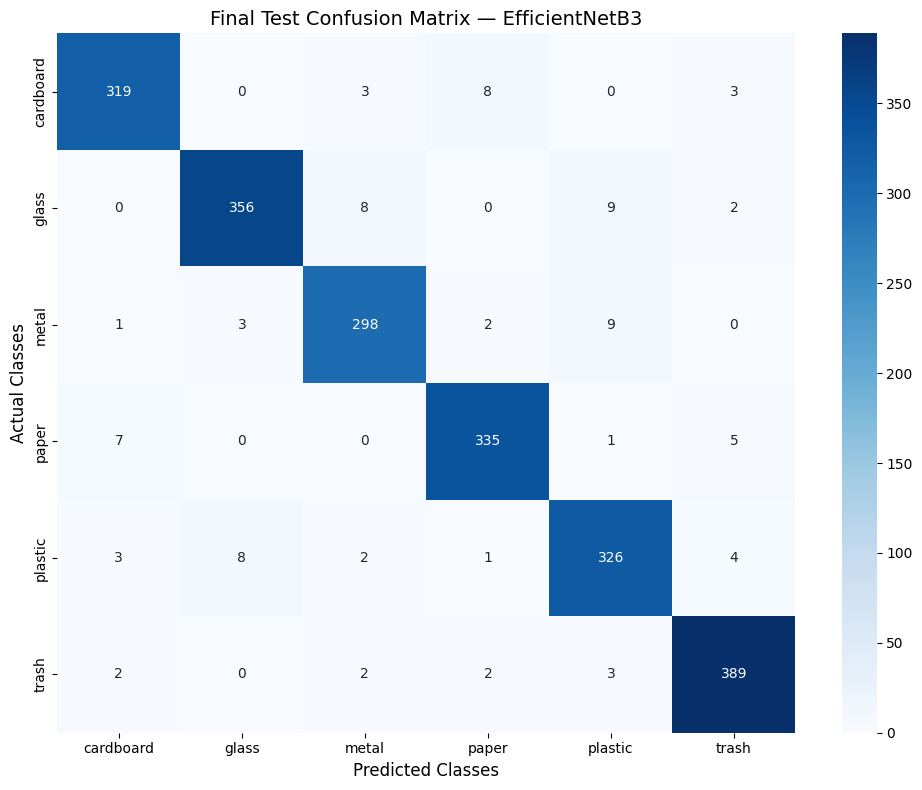

✅ Confusion matrix saved to Drive!


In [16]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(

    cm, annot=True, fmt='d',

    xticklabels=class_names,

    yticklabels=class_names,

    cmap='Blues'

)

plt.title('Final Test Confusion Matrix — EfficientNetB3', fontsize=14)

plt.ylabel('Actual Classes', fontsize=12)

plt.xlabel('Predicted Classes', fontsize=12)

plt.tight_layout()

plt.savefig('/content/drive/MyDrive/WasteModel/confusion_matrix.png', dpi=150)

plt.show()

print("✅ Confusion matrix saved to Drive!")

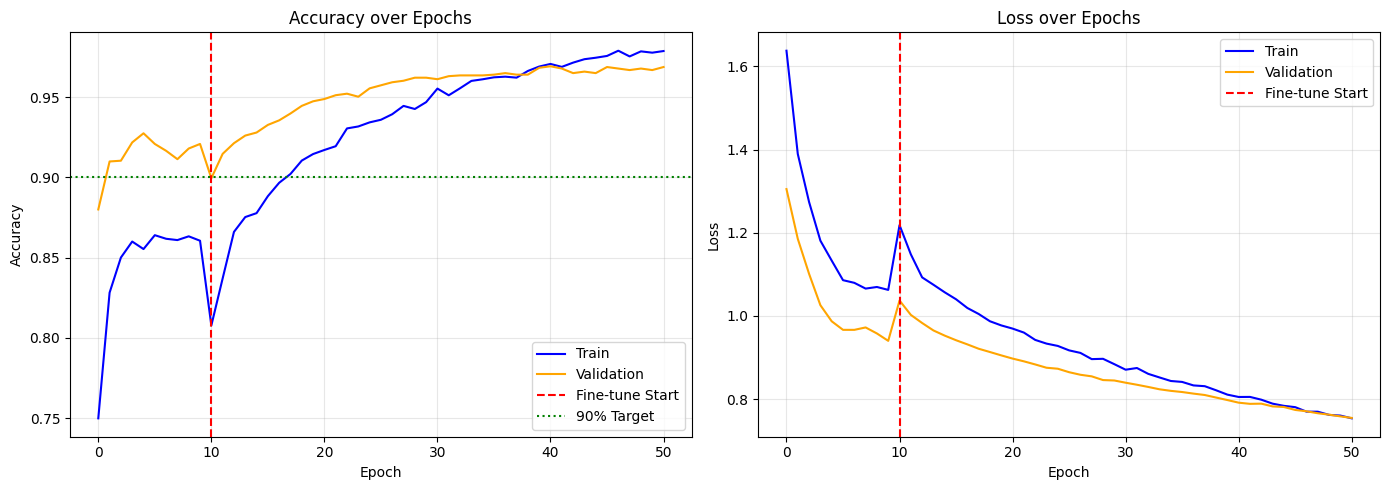

✅ Training history saved to Drive!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_acc      = history1.history['accuracy'] + history2.history['accuracy']
all_val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_loss     = history1.history['loss'] + history2.history['loss']
all_val_loss = history1.history['val_loss'] + history2.history['val_loss']
p1_end       = len(history1.history['accuracy'])

axes[0].plot(all_acc, label='Train', color='blue')
axes[0].plot(all_val_acc, label='Validation', color='orange')
axes[0].axvline(x=p1_end, color='red',
                linestyle='--', label='Fine-tune Start')
axes[0].axhline(y=0.90, color='green',
                linestyle=':', label='90% Target')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_loss, label='Train', color='blue')
axes[1].plot(all_val_loss, label='Validation', color='orange')
axes[1].axvline(x=p1_end, color='red',
                linestyle='--', label='Fine-tune Start')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WasteModel/training_history.png', dpi=150)
plt.show()
print("✅ Training history saved to Drive!")

In [18]:
model.save('/content/drive/MyDrive/WasteModel/waste_model_final.h5')
print("\n✅ Sab kuch Drive mein save ho gaya!")
print("\n📁 Google Drive → WasteModel folder mein ye files hain:")
print("   ✅ BEST_MODEL.h5           — best model")
print("   ✅ waste_model_final.h5    — final model")
print("   ✅ phase1_BEST.h5          — phase 1 best")
print("   ✅ phase1_epoch_XXX.h5     — phase 1 epochs")
print("   ✅ phase2_epoch_XXX.h5     — phase 2 epochs")
print("   ✅ confusion_matrix.png    — results")
print("   ✅ training_history.png    — graphs")


✅ Sab kuch Drive mein save ho gaya!

📁 Google Drive → WasteModel folder mein ye files hain:
   ✅ BEST_MODEL.h5           — best model
   ✅ waste_model_final.h5    — final model
   ✅ phase1_BEST.h5          — phase 1 best
   ✅ phase1_epoch_XXX.h5     — phase 1 epochs
   ✅ phase2_epoch_XXX.h5     — phase 2 epochs
   ✅ confusion_matrix.png    — results
   ✅ training_history.png    — graphs
